In [ ]:
import os
import zipfile
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [ ]:
import shutil

shutil.rmtree("dataset", ignore_errors=True)
shutil.rmtree("split_dataset", ignore_errors=True)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_path = "/content/drive/MyDrive/Colab Notebooks/Recycle/recycle.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [ ]:
print(os.listdir("dataset"))

['plastic', 'metal', 'glass', 'paper']


In [ ]:
base_dir = "dataset"
output_dir = "split_dataset"

train_ratio = 0.7
val_ratio = 0.2

classes = os.listdir(base_dir)

for split in ["train", "val", "test"]:
    for c in classes:
        os.makedirs(os.path.join(output_dir, split, c), exist_ok=True)

for c in classes:
    class_path = os.path.join(base_dir, c)
    images = os.listdir(class_path)
    random.shuffle(images)

    train_end = int(len(images) * train_ratio)
    val_end = int(len(images) * (train_ratio + val_ratio))

    for img in images[:train_end]:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(output_dir, "train", c, img))

    for img in images[train_end:val_end]:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(output_dir, "val", c, img))

    for img in images[val_end:]:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(output_dir, "test", c, img))

In [ ]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "split_dataset/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "split_dataset/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "split_dataset/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(class_names)

Found 9009 files belonging to 4 classes.
Found 2575 files belonging to 4 classes.
Found 1289 files belonging to 4 classes.
['glass', 'metal', 'paper', 'plastic']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

In [ ]:
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(150,150,3)),

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,868 (18.42 MB)

 Trainable params: 4,828,868 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 465s 2s/step - accuracy: 0.3506 - loss: 1.3326 - val_accuracy: 0.4381 - val_loss: 1.2448
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 536s 2s/step - accuracy: 0.4371 - loss: 1.2198 - val_accuracy: 0.4555 - val_loss: 1.1858
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 461s 2s/step - accuracy: 0.4779 - loss: 1.1571 - val_accuracy: 0.4722 - val_loss: 1.1633
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 469s 2s/step - accuracy: 0.5248 - loss: 1.0949 - val_accuracy: 0.5208 - val_loss: 1.1034
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 452s 2s/step - accuracy: 0.5743 - loss: 1.0074 - val_accuracy: 0.5623 - val_loss: 1.0438
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 451s 2s/step - accuracy: 0.6176 - loss: 0.9057 - val_accuracy: 0.5732 - val_loss: 1.0430
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 501s 2s/step - accuracy: 0.6789 - loss: 0.7710 - val_accuracy: 0.6085 - val_loss: 1.0481
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 452s 2s/step - accuracy: 0.7339 - loss: 0.6458 - val_accu

In [ ]:
base_model = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input

resnet_model = tf.keras.Sequential([
    tf.keras.layers.Lambda(preprocess_input),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

resnet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_resnet = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1064s 4s/step - accuracy: 0.7403 - loss: 0.6876 - val_accuracy: 0.8357 - val_loss: 0.4359
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1008s 4s/step - accuracy: 0.8267 - loss: 0.4691 - val_accuracy: 0.8567 - val_loss: 0.3967
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1038s 4s/step - accuracy: 0.8520 - loss: 0.3908 - val_accuracy: 0.8598 - val_loss: 0.3732
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1063s 4s/step - accuracy: 0.8690 - loss: 0.3506 - val_accuracy: 0.8699 - val_loss: 0.3659
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1011s 4s/step - accuracy: 0.8858 - loss: 0.3076 - val_accuracy: 0.8738 - val_loss: 0.3493
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1015s 4s/step - accuracy: 0.8972 - loss: 0.2818 - val_accuracy: 0.8757 - val_loss: 0.3644
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1029s 4s/step - accuracy: 0.9028 - loss: 0.2575 - val_accuracy: 0.8765 - val_loss: 0.3440
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1012s 4s/step - accuracy: 0.9112 - loss: 0.2348 - 

In [ ]:
cnn_loss, cnn_acc = cnn_model.evaluate(test_ds)
resnet_loss, resnet_acc = resnet_model.evaluate(test_ds)

print("CNN Accuracy:", cnn_acc)
print("ResNet Accuracy:", resnet_acc)

41/41 ━━━━━━━━━━━━━━━━━━━━ 18s 438ms/step - accuracy: 0.6183 - loss: 1.2065
41/41 ━━━━━━━━━━━━━━━━━━━━ 113s 3s/step - accuracy: 0.8790 - loss: 0.3818
CNN Accuracy: 0.6183087825775146
ResNet Accuracy: 0.8789759278297424


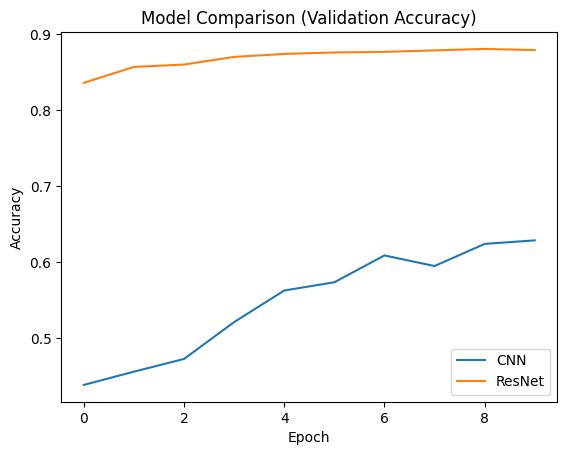

In [ ]:
plt.plot(history_cnn.history['val_accuracy'], label='CNN')
plt.plot(history_resnet.history['val_accuracy'], label='ResNet')

plt.title("Model Comparison (Validation Accuracy)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

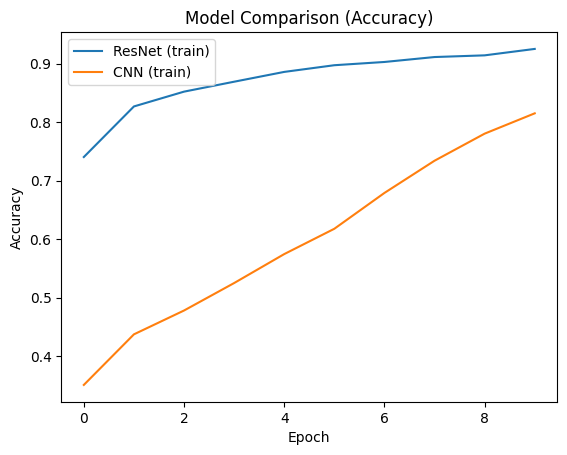

In [ ]:
plt.plot(history_resnet.history['accuracy'], label='ResNet (train)')
plt.plot(history_cnn.history['accuracy'], label='CNN (train)')

plt.title("Model Comparison (Accuracy)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()